# Intro, use this to mess around and learn data analytics techniques

In [17]:
print("Hello DailySense")

Hello DailySense


Prompt:
(Gemini Deep Research) I am trying to create a data prediction model to predict disease/problems in dogs from data collected from a sensor that measures the dog's heart rate & temperature, and uses acceleration/motion sensors & ultrasonic sensors. Please help me find some datasets with dog/canine vital signs and disease symptoms that can be used to create a predictive model. 


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, KFold

In [19]:
# Exploring cleaned_animal_disease_prediction
df = pd.read_csv('cleaned_animal_disease_prediction.csv')
display(df.head())
display(df.info())

,Animal_Type,Breed,Age,Gender,Weight,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Duration,...,Diarrhea,Coughing,Labored_Breathing,Lameness,Skin_Lesions,Nasal_Discharge,Eye_Discharge,Body_Temperature,Heart_Rate,Disease_Prediction
0,Dog,Labrador,4,Male,25.0,Fever,Lethargy,Appetite Loss,Vomiting,3 days,...,No,No,No,No,No,No,No,39.5°C,120,Parvovirus
1,Cat,Siamese,2,Female,4.5,Coughing,Sneezing,Eye Discharge,Nasal Discharge,1 week,...,No,Yes,No,No,No,Yes,Yes,38.9°C,150,Upper Respiratory Infection
2,Cow,Holstein,3,Female,600.0,Fever,Nasal Discharge,Labored Breathing,Coughing,5 days,...,No,Yes,Yes,No,No,Yes,No,40.1°C,90,Foot and Mouth Disease
3,Dog,Beagle,1,Male,10.0,Diarrhea,Vomiting,Lethargy,Appetite Loss,2 days,...,Yes,No,No,No,No,No,No,39.2°C,130,Gastroenteritis
4,Cat,Persian,5,Male,3.8,Lethargy,Appetite Loss,Skin Lesions,No,2 weeks,...,No,No,No,No,Yes,No,No,38.7°C,160,Fungal Infection


<class 'pandas.DataFrame'>
RangeIndex: 431 entries, 0 to 430
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Animal_Type         431 non-null    str    
 1   Breed               431 non-null    str    
 2   Age                 431 non-null    int64  
 3   Gender              431 non-null    str    
 4   Weight              431 non-null    float64
 5   Symptom_1           431 non-null    str    
 6   Symptom_2           431 non-null    str    
 7   Symptom_3           431 non-null    str    
 8   Symptom_4           431 non-null    str    
 9   Duration            431 non-null    str    
 10  Appetite_Loss       431 non-null    str    
 11  Vomiting            431 non-null    str    
 12  Diarrhea            431 non-null    str    
 13  Coughing            431 non-null    str    
 14  Labored_Breathing   431 non-null    str    
 15  Lameness            431 non-null    str    
 16  Skin_Lesions       

None

In [20]:
dogs_df = df[df['Animal_Type'] == 'Dog'].copy()
dogs_df['Body_Temperature'] = dogs_df['Body_Temperature'].str.replace('°C', '').astype(float)
display(dogs_df.info())

<class 'pandas.DataFrame'>
Index: 75 entries, 0 to 429
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Animal_Type         75 non-null     str    
 1   Breed               75 non-null     str    
 2   Age                 75 non-null     int64  
 3   Gender              75 non-null     str    
 4   Weight              75 non-null     float64
 5   Symptom_1           75 non-null     str    
 6   Symptom_2           75 non-null     str    
 7   Symptom_3           75 non-null     str    
 8   Symptom_4           75 non-null     str    
 9   Duration            75 non-null     str    
 10  Appetite_Loss       75 non-null     str    
 11  Vomiting            75 non-null     str    
 12  Diarrhea            75 non-null     str    
 13  Coughing            75 non-null     str    
 14  Labored_Breathing   75 non-null     str    
 15  Lameness            75 non-null     str    
 16  Skin_Lesions        75 no

None

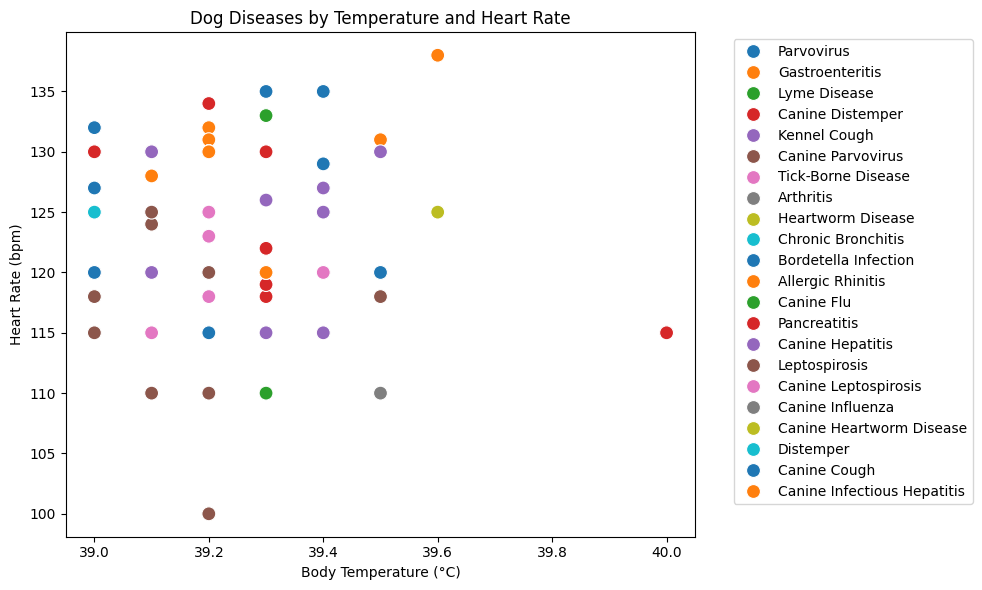

In [21]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=dogs_df, 
    x='Body_Temperature', 
    y='Heart_Rate', 
    hue='Disease_Prediction', # Color the dots based on the disease
    palette='tab10', 
    s=100
)
plt.title('Dog Diseases by Temperature and Heart Rate')
plt.xlabel('Body Temperature (°C)')
plt.ylabel('Heart Rate (bpm)')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('dog_disease_scatter.png')

In [22]:
# KNN First pass
X = dogs_df[['Body_Temperature', 'Heart_Rate']]
y = dogs_df['Disease_Prediction']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 13.33%


In [23]:
#KNN K-Folds validation
X = dogs_df[['Body_Temperature', 'Heart_Rate']]
y = dogs_df['Disease_Prediction']
pipeline = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=3))
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline, X, y, cv=kf, scoring='accuracy')
print(f"Scores for each fold: {cv_scores}")
print(f"Average CV Accuracy: {np.mean(cv_scores) * 100:.2f}%")




Scores for each fold: [0.13333333 0.33333333 0.06666667 0.06666667 0.06666667]
Average CV Accuracy: 13.33%


In [24]:
# Exploring Dog Health Vitals
csv_path = '../data/Dog Health Vitals Dataset (CC Liscense)/dog_vitals_dataset.csv'
df = pd.read_csv(csv_path)
print(df.head())


                        _id                               ecg_path  duration  \
0  62271dc2b9baee839b0c1e99  ecg_data/62271dc2b9baee839b0c1e99.wav    300.12   
1  62271ea0be903091edb2bf09  ecg_data/62271ea0be903091edb2bf09.wav    300.08   
2  622723bebe903091edb2bf0b  ecg_data/622723bebe903091edb2bf0b.wav    300.08   
3  622776fabe903091edb2bf0d  ecg_data/622776fabe903091edb2bf0d.wav    300.14   
4  622799e5ea79f8f9cc02b284  ecg_data/622799e5ea79f8f9cc02b284.wav    300.12   

   pet_id breeds  weight  age  \
0      14  boxer    34.0  4.5   
1      14  boxer    34.0  4.5   
2      14  boxer    34.0  4.5   
3      14  boxer    34.0  4.5   
4      14  boxer    34.0  4.5   

                                         segments_br  \
0     [{'deb': 200.0, 'fin': 240.0, 'value': 13.24}]   
1  [{'deb': 240.0, 'fin': 280.0, 'value': 12.34},...   
2  [{'deb': 210.0, 'fin': 250.0, 'value': 12.01},...   
3       [{'deb': 50.0, 'fin': 90.0, 'value': 13.13}]   
4     [{'deb': 100.0, 'fin': 140.0, 'val

In [25]:
from scipy.io import wavfile
import os
wav_filename = '62bcd17b56685c685a0a4028.wav'
full_wav_path = f'../data/Dog Health Vitals Dataset (CC Liscense)/ecg_data/{wav_filename}'
sample_rate, data = wavfile.read(full_wav_path)
print(f"WAV Loaded successfully! Sample rate: {sample_rate}")

WAV Loaded successfully! Sample rate: 130


In [26]:
row_index = 0
csv_ecg_path = df.loc[row_index, 'ecg_path']
working_path = os.path.join('../data/Dog Health Vitals Dataset (CC Liscense)', csv_ecg_path)
sample_rate, data = wavfile.read(working_path)

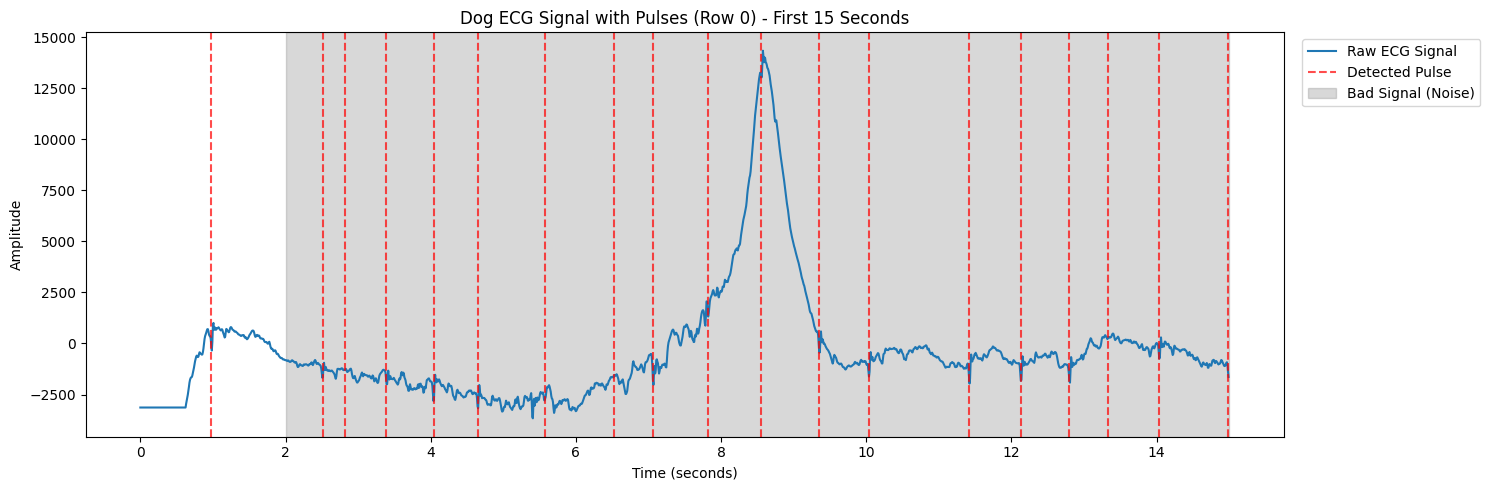

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import ast

time = np.arange(len(data)) / sample_rate
pulses_str = str(df.loc[row_index, 'ecg_pulses'])
pulses = ast.literal_eval(pulses_str) if pulses_str != 'nan' else []
bad_ecg_str = str(df.loc[row_index, 'bad_ecg'])
bad_ecg_regions = ast.literal_eval(bad_ecg_str) if bad_ecg_str != 'nan' else []

plt.figure(figsize=(15, 5))
mask = time < 15 
plt.plot(time[mask], data[mask], label='Raw ECG Signal', color='#1f77b4')

pulse_labeled = False
for p in pulses:
    if p < 15: # Only draw pulses that fall within our 15-second window
        plt.axvline(x=p, color='red', linestyle='--', alpha=0.7, 
                    label='Detected Pulse' if not pulse_labeled else "")
        pulse_labeled = True

bad_labeled = False
for region in bad_ecg_regions:
    start, end = region
    if start < 15:
        # Cap the end of the shaded region at 15 seconds for this zoomed-in plot
        plt.axvspan(start, min(end, 15), color='gray', alpha=0.3, 
                    label='Bad Signal (Noise)' if not bad_labeled else "")
        bad_labeled = True

plt.title(f'Dog ECG Signal with Pulses (Row {row_index}) - First 15 Seconds')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')

plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

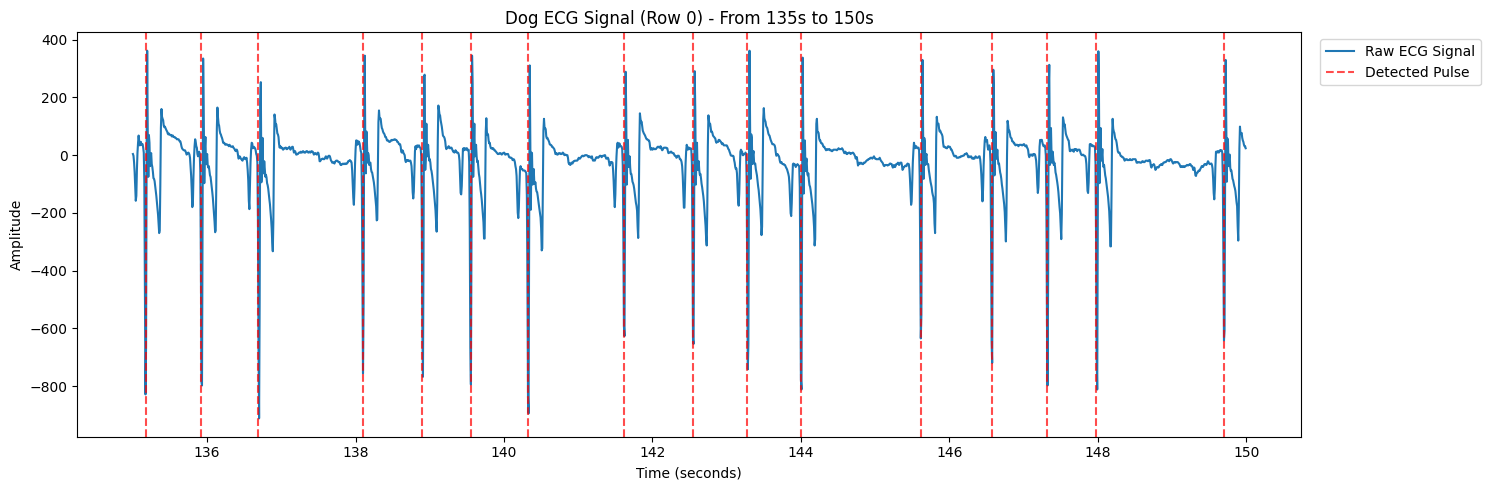

In [28]:
import matplotlib.pyplot as plt
import numpy as np
import ast

# Define the start and end times you want to look at
start_time = 135  # Start at 30 seconds
end_time = 150    # End at 45 seconds

# 1. Create a time axis in seconds
time = np.arange(len(data)) / sample_rate

# 2. Parse the pulse and bad_ecg data
pulses_str = str(df.loc[row_index, 'ecg_pulses'])
pulses = ast.literal_eval(pulses_str) if pulses_str != 'nan' else []

bad_ecg_str = str(df.loc[row_index, 'bad_ecg'])
bad_ecg_regions = ast.literal_eval(bad_ecg_str) if bad_ecg_str != 'nan' else []

# 3. Create the Visualization
plt.figure(figsize=(15, 5))

# Create a mask that only selects data between start_time and end_time
mask = (time >= start_time) & (time < end_time) 
plt.plot(time[mask], data[mask], label='Raw ECG Signal', color='#1f77b4')

# Overlay the heart pulses
pulse_labeled = False
for p in pulses:
    if start_time <= p < end_time: # Only draw pulses within our specific window
        plt.axvline(x=p, color='red', linestyle='--', alpha=0.7, 
                    label='Detected Pulse' if not pulse_labeled else "")
        pulse_labeled = True

# Overlay the bad ECG regions
bad_labeled = False
for region in bad_ecg_regions:
    start, end = region
    # Check if the bad region overlaps with our current viewing window
    if start < end_time and end > start_time:
        # Cap the shading so it doesn't bleed outside our graph
        plt.axvspan(max(start, start_time), min(end, end_time), color='gray', alpha=0.3, 
                    label='Bad Signal (Noise)' if not bad_labeled else "")
        bad_labeled = True

plt.title(f'Dog ECG Signal (Row {row_index}) - From {start_time}s to {end_time}s')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')

plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

Summary of Average Heart Rates (bpm):
count    968.000000
mean      61.073247
std       10.405237
min       36.243333
25%       54.005809
50%       59.997143
75%       68.226398
max       96.756957
Name: Average_HR, dtype: float64


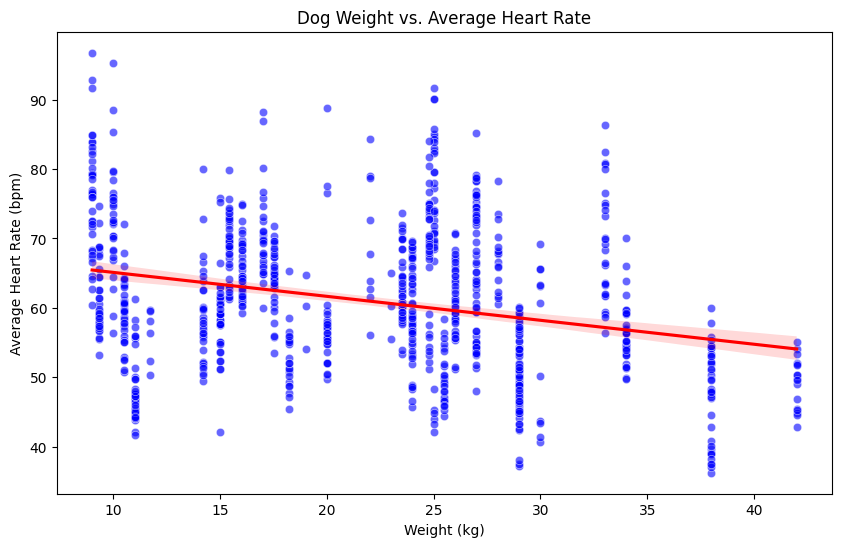

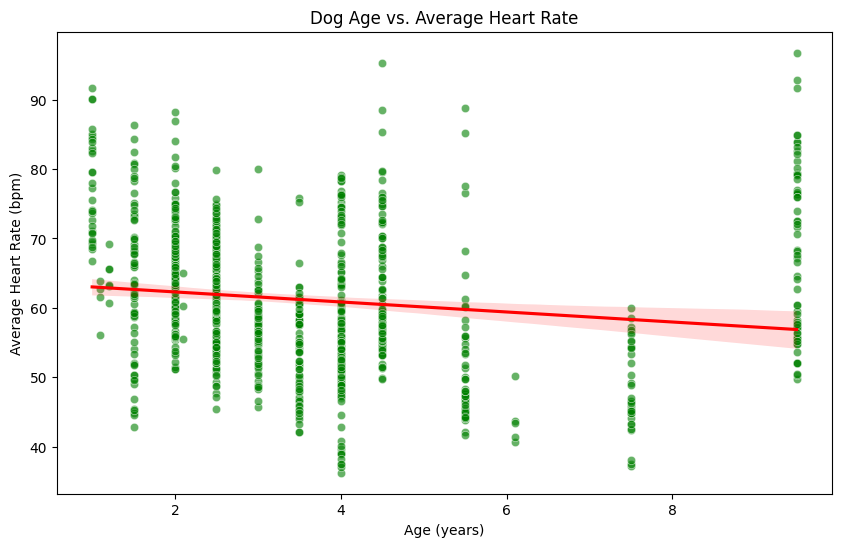

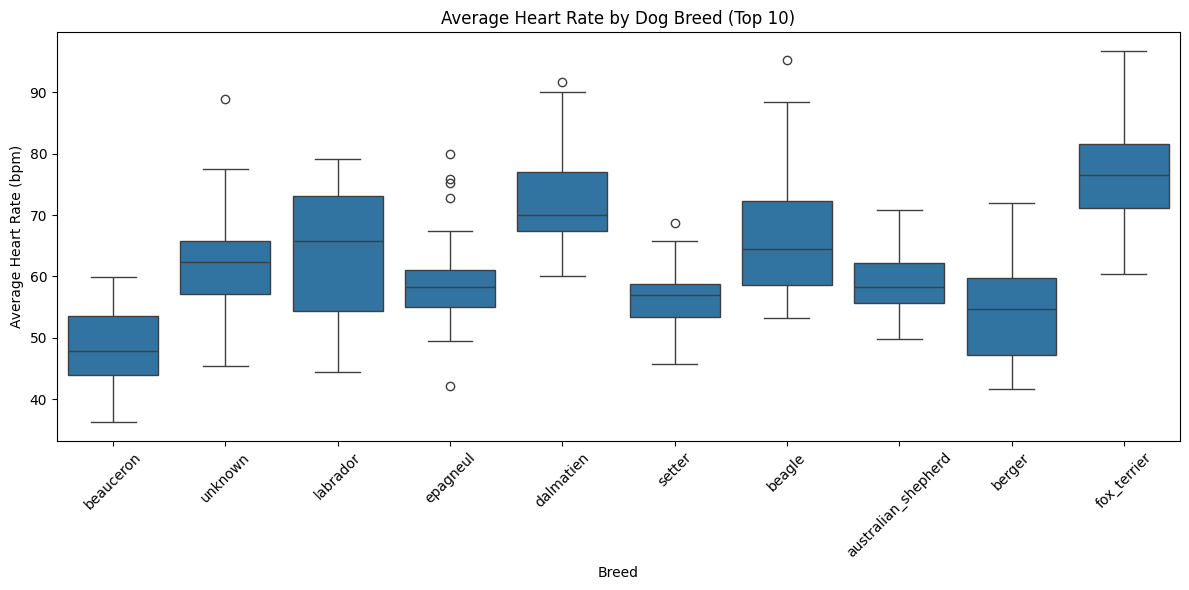

In [29]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset (Use your relative path here if needed)
df = pd.read_csv(csv_path)

# 2. Data Transformation: Function to extract average HR
def get_avg_hr(hr_str):
    # If the row is empty (NaN), return NaN
    if pd.isna(hr_str):
        return np.nan
    try:
        # Convert the string "['{...}']" into a real Python list of dictionaries
        hr_list = ast.literal_eval(hr_str)
        if not hr_list:
            return np.nan
            
        # Extract the 'value' from every dictionary in the list
        values = [segment['value'] for segment in hr_list if 'value' in segment]
        
        # Return the mathematical mean of all the heart rate segments
        return np.mean(values) if values else np.nan
    except:
        return np.nan

# 3. Apply the function to create a brand new column
df['Average_HR'] = df['segments_hr'].apply(get_avg_hr)

# Filter out rows that had no heart rate data
eda_df = df.dropna(subset=['Average_HR'])

# 4. Print Summary Statistics
print("Summary of Average Heart Rates (bpm):")
print(eda_df['Average_HR'].describe())

# 5. Create Scatter Plot for Weight
plt.figure(figsize=(10, 6))
sns.scatterplot(data=eda_df, x='weight', y='Average_HR', alpha=0.6, color='blue')
# Add a trendline to make the relationship clearer
sns.regplot(data=eda_df, x='weight', y='Average_HR', scatter=False, color='red') 
plt.title('Dog Weight vs. Average Heart Rate')
plt.xlabel('Weight (kg)')
plt.ylabel('Average Heart Rate (bpm)')
plt.show()


# Age vs Heart Rate
plt.figure(figsize=(10, 6))
sns.scatterplot(data=eda_df, x='age', y='Average_HR', alpha=0.6, color='green')
sns.regplot(data=eda_df, x='age', y='Average_HR', scatter=False, color='red')
plt.title('Dog Age vs. Average Heart Rate')
plt.xlabel('Age (years)')
plt.ylabel('Average Heart Rate (bpm)')
plt.show()


# 6. Create Box Plot for Breeds
plt.figure(figsize=(12, 6))
# Only grab the top 10 most common breeds so the chart isn't crowded
top_breeds = eda_df['breeds'].value_counts().nlargest(10).index
subset_df = eda_df[eda_df['breeds'].isin(top_breeds)]

sns.boxplot(data=subset_df, x='breeds', y='Average_HR')
plt.title('Average Heart Rate by Dog Breed (Top 10)')
plt.xlabel('Breed')
plt.ylabel('Average Heart Rate (bpm)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Status
Normal      919
Abnormal     49
Name: count, dtype: int64


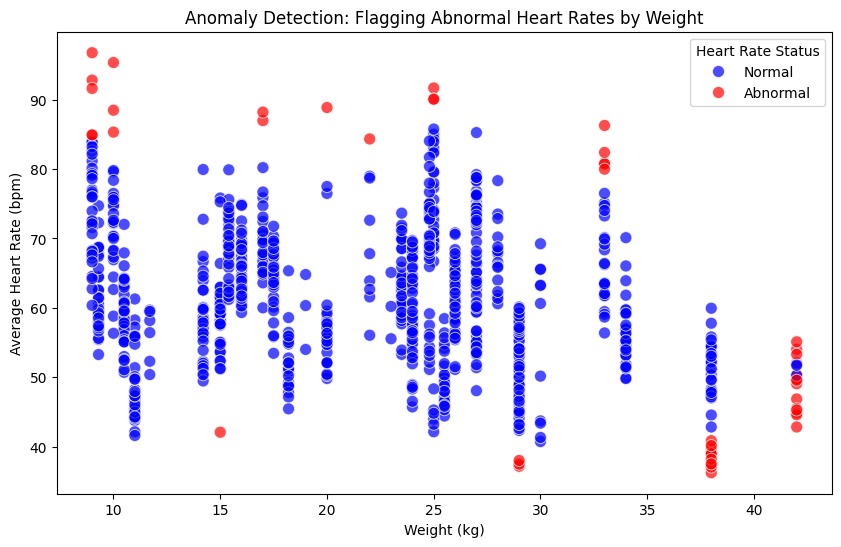

In [30]:
# Building Anomaly Detection for Heart Rate
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest

# 1. Assuming you already have 'eda_df' from the previous step with 'Average_HR'
# Let's drop any rows that are missing Weight, Age, or HR
ml_df = eda_df.dropna(subset=['Average_HR', 'weight', 'age']).copy()

# 2. Define the features we want the model to look at
# We want to find abnormal heart rates relative to the dog's size
features = ml_df[['weight', 'Average_HR']]

# 3. Initialize the Isolation Forest Model
# 'contamination' is our guess of what percentage of dogs might have abnormal vitals (e.g., 5%)
model = IsolationForest(contamination=0.05, random_state=42)

# 4. Train the model and make predictions in one step
# It will return 1 for "Normal" and -1 for "Anomaly"
ml_df['Anomaly_Score'] = model.fit_predict(features)

# 5. Make the labels easy to read
ml_df['Status'] = ml_df['Anomaly_Score'].map({1: 'Normal', -1: 'Abnormal'})

print(ml_df['Status'].value_counts())

# 6. Visualize the results
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=ml_df, 
    x='weight', 
    y='Average_HR', 
    hue='Status', 
    palette={'Normal': 'blue', 'Abnormal': 'red'},
    alpha=0.7,
    s=75
)
plt.title('Anomaly Detection: Flagging Abnormal Heart Rates by Weight')
plt.xlabel('Weight (kg)')
plt.ylabel('Average Heart Rate (bpm)')
plt.legend(title='Heart Rate Status')
plt.show()


In [31]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt

# 1. Load the dataset (Use your relative path if needed)
# df = pd.read_csv(csv_path)

# 2. Define a function to calculate Heart Rate Variability (HRV)
def calculate_hrv(pulses_str):
    if pd.isna(pulses_str):
        return np.nan
    try:
        # Convert the string to a real Python list
        pulses = ast.literal_eval(pulses_str)
        
        # We need at least 2 pulses to calculate a time difference
        if len(pulses) < 2:
            return np.nan
            
        # np.diff calculates the difference between consecutive numbers in a list
        # E.g., [1.0, 2.0, 3.5] becomes [1.0, 1.5]
        rr_intervals = np.diff(pulses)
        
        # Calculate the Standard Deviation of these time intervals
        # Higher standard deviation means more irregular (Arrhythmia)
        variability = np.std(rr_intervals)
        return variability
    except:
        return np.nan

# 3. Apply the function to create a new column
df['Heart_Variability'] = df['ecg_pulses'].apply(calculate_hrv)

# 4. Sort the dogs by the most irregular heartbeats
valid_df = df.dropna(subset=['Heart_Variability']).copy()
arrhythmia_dogs = valid_df.sort_values(by='Heart_Variability', ascending=False)

print("--- TOP 5 DOGS WITH HIGHEST IRREGULARITY (Potential Arrhythmia) ---")
print(arrhythmia_dogs[['pet_id', 'breeds', 'Average_HR', 'Heart_Variability']].head())

print("\n--- TOP 5 DOGS WITH LOWEST IRREGULARITY (Steady Heartbeat) ---")
print(arrhythmia_dogs[['pet_id', 'breeds', 'Average_HR', 'Heart_Variability']].tail())

--- TOP 5 DOGS WITH HIGHEST IRREGULARITY (Potential Arrhythmia) ---
      pet_id    breeds  Average_HR  Heart_Variability
326       23  doberman         NaN          11.792953
609       27  labrador         NaN           2.983121
611       27  labrador         NaN           2.847409
521        1    beagle         NaN           2.644056
1060      33  samoyede   44.803333           2.557428

--- TOP 5 DOGS WITH LOWEST IRREGULARITY (Steady Heartbeat) ---
     pet_id       breeds  Average_HR  Heart_Variability
654      24  fox_terrier   96.756957           0.104183
183      21    dalmatien         NaN           0.097207
542      16    dalmatien         NaN           0.086778
541      16    dalmatien         NaN           0.084973
547      16    dalmatien         NaN           0.082209


In [32]:
import pandas as pd
import numpy as np
import ast

# 1. Load the dataset (Use your relative path if needed)
# df = pd.read_csv('../data_files/dog_vitals_dataset.csv')

def calculate_quality_metrics(row):
    # Calculate Total Beats
    try:
        pulses = ast.literal_eval(str(row['ecg_pulses']))
        total_beats = len(pulses)
    except:
        total_beats = 0
        
    # Calculate Noise Ratio (How much of the recording is 'bad_ecg'?)
    try:
        bad_regions = ast.literal_eval(str(row['bad_ecg']))
        # Sum up the duration (end - start) of every bad region
        bad_duration = sum([end - start for start, end in bad_regions])
        # Divide by the total recording duration to get a percentage (0.0 to 1.0)
        bad_ratio = bad_duration / row['duration']
    except:
        bad_ratio = 0.0
        
    return pd.Series({'total_beats': total_beats, 'bad_ratio': bad_ratio})

# 2. Apply the function to create two new columns in your DataFrame
metrics = df.apply(calculate_quality_metrics, axis=1)
df = pd.concat([df, metrics], axis=1)

print(f"Original dataset size: {len(df)} dogs")

# 3. FILTER THE DATA
# Let's define a "reasonable" recording as having at least 100 beats 
# AND being less than 50% noise (bad_ratio < 0.5)
clean_df = df[(df['total_beats'] >= 100) & (df['bad_ratio'] < 0.5)].copy()

print(f"Clean dataset size: {len(clean_df)} dogs")
print(f"Removed {len(df) - len(clean_df)} noisy/unreliable recordings!")

# Let's see the most reliable dogs now
print("\n--- TOP 5 CLEANEST RECORDINGS ---")
print(clean_df[['pet_id', 'breeds', 'total_beats', 'bad_ratio']].head())



Original dataset size: 1123 dogs
Clean dataset size: 947 dogs
Removed 176 noisy/unreliable recordings!

--- TOP 5 CLEANEST RECORDINGS ---
   pet_id breeds  total_beats  bad_ratio
2      14  boxer        292.0   0.346574
5      14  boxer        300.0   0.346470
6      14  boxer        266.0   0.000000
7      14  boxer        324.0   0.207057
8      14  boxer        307.0   0.259896


Calculated 95th Percentile Threshold for Arrhythmia: 0.57

Number of dogs labeled with Arrhythmia vs Normal:
Has_Arrhythmia
0    871
1     46
Name: count, dtype: int64

--- Logistic Regression Results ---
              precision    recall  f1-score   support

           0       1.00      0.88      0.94       173
           1       0.35      1.00      0.52        11

    accuracy                           0.89       184
   macro avg       0.68      0.94      0.73       184
weighted avg       0.96      0.89      0.91       184



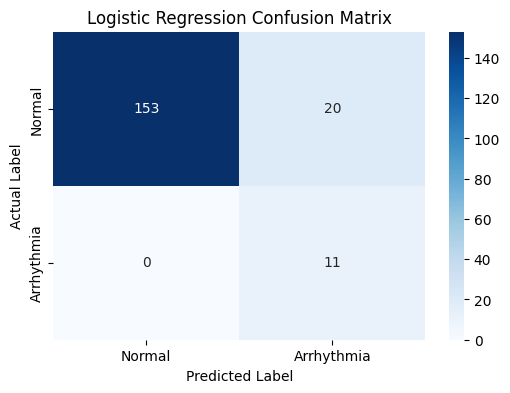

In [33]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Assuming you have your 'clean_df' from the previous step with 'Heart_Variability' calculated
ml_df = clean_df.dropna(subset=['Heart_Variability', 'weight', 'age', 'Average_HR']).copy()

# 2. SET THE THRESHOLD (Statistical Approach: 95th Percentile)
threshold = np.percentile(ml_df['Heart_Variability'], 95)
print(f"Calculated 95th Percentile Threshold for Arrhythmia: {threshold:.2f}")

# Create the Target Label (1 for Arrhythmia, 0 for Normal)
ml_df['Has_Arrhythmia'] = (ml_df['Heart_Variability'] >= threshold).astype(int)

print("\nNumber of dogs labeled with Arrhythmia vs Normal:")
print(ml_df['Has_Arrhythmia'].value_counts())

# 3. PREPARE FOR LOGISTIC REGRESSION
# Can we predict this arrhythmia using just Age, Weight, and Average HR?
X = ml_df[['age', 'weight', 'Average_HR']]
y = ml_df['Has_Arrhythmia']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. TRAIN THE MODEL
log_reg = LogisticRegression(class_weight='balanced') # 'balanced' helps since Arrhythmia is rare (5%)
log_reg.fit(X_train_scaled, y_train)

# 5. EVALUATE THE MODEL
y_pred = log_reg.predict(X_test_scaled)

print("\n--- Logistic Regression Results ---")
print(classification_report(y_test, y_pred))

# Plot the Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Arrhythmia'], yticklabels=['Normal', 'Arrhythmia'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Logistic Regression Confusion Matrix')
plt.show()